In [2]:
!pip install tensorflow


   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
    --------------------------------------- 5.0/332.0 MB 26.6 MB/s eta 0:00:13
   - -------------------------------------- 14.4/332.0 MB 35.6 MB/s eta 0:00:09
   -- ------------------------------------- 23.6/332.0 MB 38.3 MB/s eta 0:00:09
   --- ------------------------------------ 31.5/332.0 MB 37.8 MB/s eta 0:00:08
   ---- ----------------------------------- 38.0/332.0 MB 36.4 MB/s eta 0:00:09
   ----- ---------------------------------- 42.5/332.0 MB 34.0 MB/s eta 0:00:09
   ----- ---------------------------------- 48.5/332.0 MB 32.9 MB/s eta 0:00:09
   ------ --------------------------------- 54.8/332.0 MB 32.2 MB/s eta 0:00:09
   ------- -------------------------------- 60.0/332.0 MB 31.5 MB/s eta 0:00:09
   ------- -------------------------------- 65.3/332.0 MB 31.0 MB/s eta 0:00:09
   -------- ------------------------------- 70.8/332.0 MB 30.4 MB/s eta 0:00:09
   -------- ------------------------------- 74.4/3

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from sklearn.model_selection import KFold
import datetime

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'


In [3]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [4]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [5]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [6]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0006", "B0007"]
test_file = "B0018"

In [7]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)


In [8]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [9]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
#test_target_column_index = test_data.columns.get_loc("Original_Signal")
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-LSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                       input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # LSTM layers
        LSTM(64, return_sequences=False, activation='relu'),
        
        
        # Dense output layer
        Dense(1)
    ])
    

   

    

    # Reshape input data for CNN-LSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    #model.compile(optimizer='adam', loss='mse')
    #model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0027),
    #             loss='mse')
    model.compile(optimizer='adam', loss='mse')
    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store the metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate the model on the test dataset
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (498, 2, 4)
Combined target data shape: (498,)
Test data shape: (130, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - loss: 0.1656 - val_loss: 0.0285
Epoch 2/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0368 - val_loss: 0.0228
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0171 - val_loss: 0.0066
Epoch 4/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0049 - val_loss: 0.0020
Epoch 5/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0015 - val_loss: 7.9030e-04
Epoch 6/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0011 - val_loss: 6.0866e-04
Epoch 7/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.0505e-04 - val_loss: 4.3930e-04
Epoch 8/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7.1604e-04 - val_loss: 3.6191e-04
Epoch 9/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.8900e-04 - val_loss: 3.0639e-04
Epoch 10/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.9936e-04 - val_loss: 3.4952e-04
Epoch 11/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.5013e-04 - val_loss: 3.

In [10]:

# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0034090193
Mean Squared Error (MSE): 0.0000275120
Root Mean Squared Error (RMSE): 0.0052451889
R2 Score: 0.9951832
Mean Absolute Percentage Error (MAPE): 0.4363140%


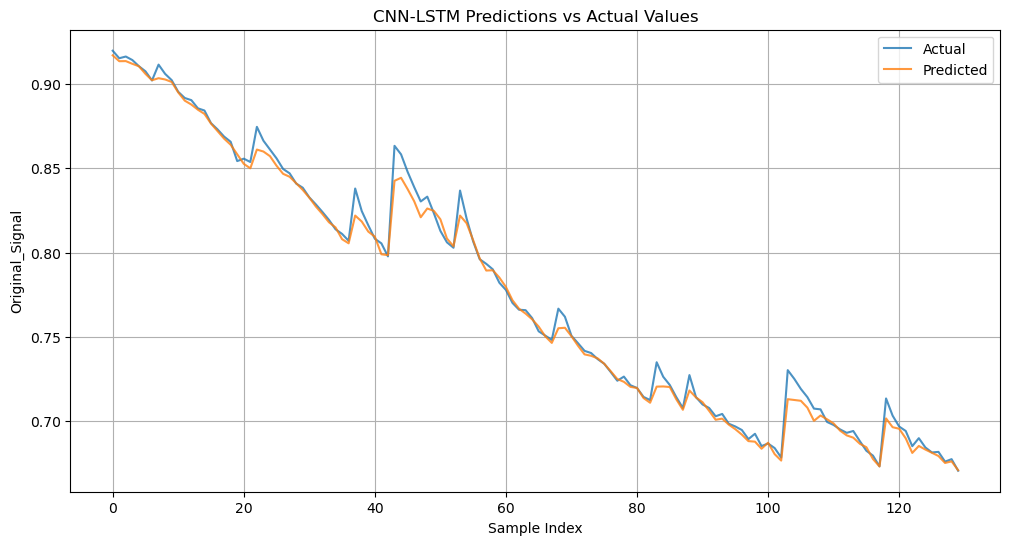


Output shapes:
Actual values shape: (130,)
Predicted values shape: (130,)


In [11]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")


In [14]:
 # Save results
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted': y_pred_actual,
    'Error': y_test_actual - y_pred_actual
})
predictions_filename = f'CNN_lstm_predictions_{test_file}_{timestamp}.csv'
predictions_df.to_csv(predictions_filename, index=True)
    
    # Save metrics
metrics_df = pd.DataFrame({
    'Metric': ['Test Loss', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE'],
    'Value': [test_loss, mae, mse, rmse, r2, mape]
})
metrics_filename = f'CNN_lstm_metrics_{test_file}_{timestamp}.csv'
metrics_df.to_csv(metrics_filename, index=False)
    

#With B0005 AS TEST FILE

In [15]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [16]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [17]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [18]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [23]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0018", "B0006", "B0007"]
test_file = "B0005"

In [24]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)


In [25]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [26]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
#test_target_column_index = test_data.columns.get_loc("Original_Signal")
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-LSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                       input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # LSTM layers
        LSTM(64, return_sequences=False, activation='relu'),
        
        
        # Dense output layer
        Dense(1)
    ])
    

   

    

    # Reshape input data for CNN-LSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    #model.compile(optimizer='adam', loss='mse')
    #model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0027),
    #             loss='mse')
    model.compile(optimizer='adam', loss='mse')
    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store the metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate the model on the test dataset
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]

Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 270ms/step - loss: 0.1592 - val_loss: 0.0296
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0417 - val_loss: 0.0204
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0192 - val_loss: 0.0091
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0071 - val_loss: 0.0024
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0024 - val_loss: 9.8601e-04
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0016 - val_loss: 9.8735e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0013 - val_loss: 9.0709e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0011 - val_loss: 7.2521e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 9.7078e-04 - val_loss: 6.5123e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 8.6107e-04 - val_loss: 5.6430e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 7.6099e-04 - val_loss: 4.8433e-04

In [27]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0020597105
Mean Squared Error (MSE): 0.0000069555
Root Mean Squared Error (RMSE): 0.0026373193
R2 Score: 0.9992169
Mean Absolute Percentage Error (MAPE): 0.2622522%


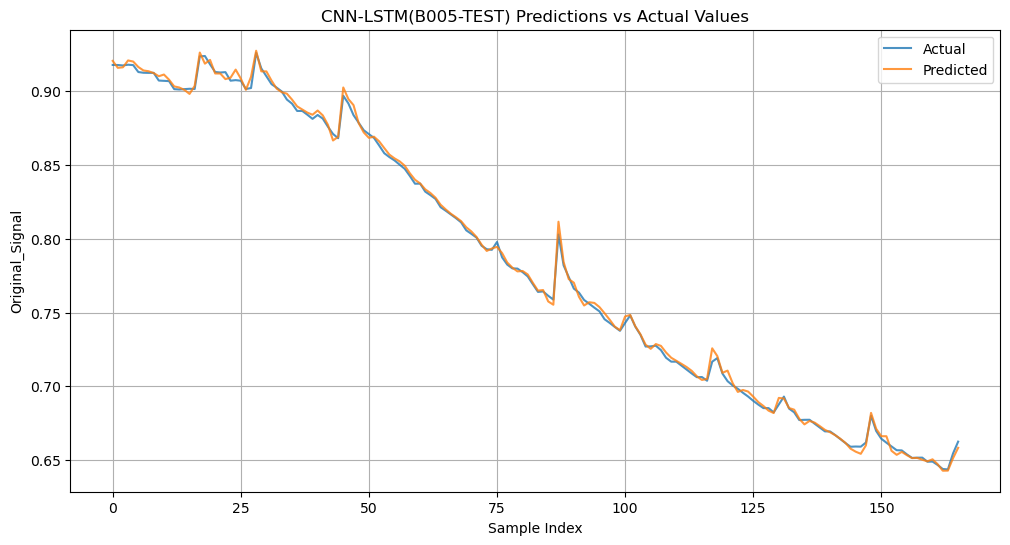


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [28]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM(B005-TEST) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")


#B006 AS TEST DATA

In [29]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [30]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [31]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [32]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [37]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0018", "B0007"]
test_file = "B0006"

In [38]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [39]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [40]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
#test_target_column_index = test_data.columns.get_loc("Original_Signal")
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-LSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                       input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # LSTM layers
        LSTM(64, return_sequences=False, activation='relu'),
        
        
        # Dense output layer
        Dense(1)
    ])
    

   

    

    # Reshape input data for CNN-LSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    #model.compile(optimizer='adam', loss='mse')
    #model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0027),
    #             loss='mse')
    model.compile(optimizer='adam', loss='mse')
    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store the metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate the model on the test dataset
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]

Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - loss: 0.1664 - val_loss: 0.0315
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0440 - val_loss: 0.0231
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0205 - val_loss: 0.0094
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0072 - val_loss: 0.0024
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 9.0448e-04 - val_loss: 0.0012
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 8.6613e-04 - val_loss: 0.0011
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 7.9800e-04 - val_loss: 9.8504e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 7.4165e-04 - val_loss: 8.8799e-04
Epoch 12/1000
10

In [41]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0030390889
Mean Squared Error (MSE): 0.0000190950
Root Mean Squared Error (RMSE): 0.0043697838
R2 Score: 0.9987490
Mean Absolute Percentage Error (MAPE): 0.3893612%


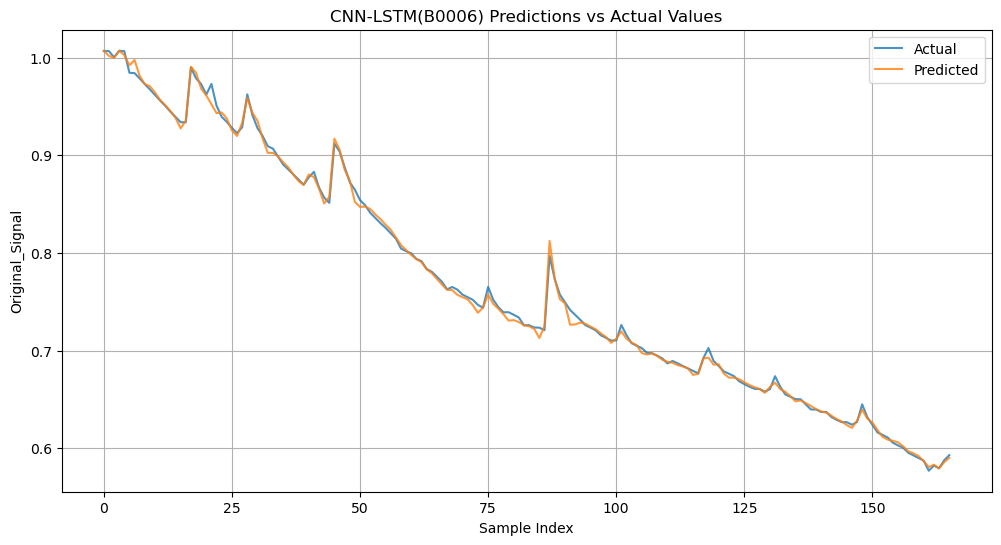


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [42]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM(B0006) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [2]:
#b0007

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [3]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [4]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [5]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [6]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0006", "B0018"]
test_file = "B0007"

In [7]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [8]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [9]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
#test_target_column_index = test_data.columns.get_loc("Original_Signal")
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-LSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                       input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # LSTM layers
        LSTM(64, return_sequences=False, activation='relu'),
        
        
        # Dense output layer
        Dense(1)
    ])
    

   

    

    # Reshape input data for CNN-LSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    #model.compile(optimizer='adam', loss='mse')
    #model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0027),
    #             loss='mse')
    model.compile(optimizer='adam', loss='mse')
    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store the metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate the model on the test dataset
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]

Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.1519 - val_loss: 0.0304
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0400 - val_loss: 0.0220
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0197 - val_loss: 0.0090
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0068 - val_loss: 0.0022
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0013 - val_loss: 9.9443e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012 - val_loss: 7.8976e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.9732e-04 - val_loss: 6.9855e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.1577e-04 - val_loss: 6.6364e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.3025e-04 - val_loss: 5.7394e-04
Epoch 12/

In [10]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0020183222
Mean Squared Error (MSE): 0.0000090455
Root Mean Squared Error (RMSE): 0.0030075799
R2 Score: 0.9985727
Mean Absolute Percentage Error (MAPE): 0.2490316%


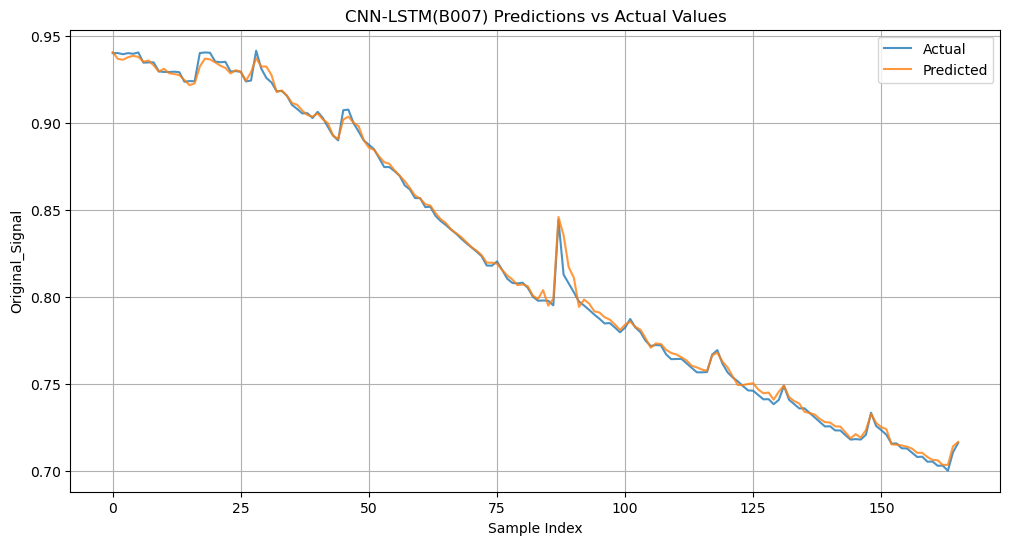


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [11]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM(B007) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [12]:
model.summary()
total_params = model.count_params()
print(f"Total trainable parameters in {model.name if hasattr(model, 'name') else 'model'}: {total_params:,}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ time_distributed_10           │ (None, 2, 4, 128)     │          256 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_11           │ (None, 2, 4, 128)     │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_12           │ (None, 2, 4, 128)     │       16,512 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_13           │ (None, 2, 4, 128)     │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_14           │ (None, 2, 512)        │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_2 (LSTM)                 │ (None, 64)            │      147,712 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)               │ (None, 1)             │           65 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 493,637 (1.88 MB)

 Trainable params: 164,545 (642.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 329,092 (1.26 MB)

Total trainable parameters in sequential_2: 164,545
